## Description

This is mostly derived from `fourcastnext`. It is used to illustrate how to create a similar "inference" pipeline using PET persistence model.

In [1]:
# Most users should change this to the current directory.
# os.environ['ERA5LOWRESDEMO'] = os.path.abspath('/tmp/')

# NOTE: /var/tmp/ is used for longer running tasks and persistence that's required across reboots
import os
os.environ['ERA5LOWRESDEMO'] = os.path.abspath('/var/tmp/era5demo_persistence')
os.makedirs(os.environ['ERA5LOWRESDEMO'], exist_ok=True)
EXPERIMENT_VERSION='v1'



In [2]:

import pathlib
import xarray as xr
from pathlib import Path
import pyearthtools.tutorial
import pyearthtools.pipeline

# The following are derived from the mini demo fourcastnext tutorial but not used here.

# ---
# unsure what these are for:
# ---
# import hydra
# from omegaconf import OmegaConf
# ---

# ---
# we are downloading from the internet. Does this register the archive?
# ---
# import pyearthtools.data
# import pyearthtools.data.archive
# ---

# ---
# training  not required
# ---
# import pyearthtools.training
# import fourcastnext
# ---

# ---
# no gpu required
# ---
# import torch; torch.set_default_device(<YOUR_DEVICE_HERE>)  # Uncomment and set this if you need to configure a non-default device.
# ---

In [3]:
workdir = os.environ['ERA5LOWRESDEMO']
file_location = workdir + '/mini.nc'
name_vars = [
    '10m_u_component_of_wind', 
    '10m_v_component_of_wind', 
    '2m_temperature', 
    'mean_sea_level_pressure',
]
print(f'This tutorial will download a copy of the input data to {workdir}. It will also create model checkpoint files and other data here.')
print(f"This is a light weight example and will only use the following variables: {name_vars}")

This tutorial will download a copy of the input data to /var/tmp/era5demo_persistence. It will also create model checkpoint files and other data here.
This is a light weight example and will only use the following variables: ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure']


In [4]:
if not os.path.exists(file_location):
    print("Training data not found, downloading around 2.8GB of data")
    era5_lowres = xr.open_zarr('gs://weatherbench2/datasets/era5/1959-2022-6h-64x32_equiangular_conservative.zarr')
    subset = era5_lowres[name_vars]
    subset.to_netcdf(file_location)
    print(f"Wrote file to {file_location}")
    assert os.path.exists(file_location)
else:
    print(f"File already downloaded ({file_location}), skipping ...")

File already downloaded (/var/tmp/era5demo_persistence/mini.nc), skipping ...


In [5]:
accessor = pyearthtools.tutorial.ERA5DataClass.ERA5LowResDemoIndex(
    name_vars,
    filename_override=file_location
)

In [6]:
# --- scratch space/workings ---
# 1. data is in 6 hour intervals
# 2. we want the past 6 indices for median to work, so taking 2 days is sufficient without breaking the intervals
# 3. explicitly set the time update to 6 hours since the median will be performed on every index using past 3 indices (but padded to 8 for safety/imputation)
# ---
# SequentialRetrieval works like this:
# (a, b, c)
# a = start
# b = number of values to get
# c = interval or how many values to skip
# ---
# TemporalRetrieval does the same, but each index is a delta-unit mapping - so we need to reverse engineer a bit
# !!! IMPORTANT !!!
#    > The circumstance here is that time is already 6 hourly windows and in chunks of 4.
#    > Something about the behaviour has changed, causing the window to select 4 indices at a time.
#    > Due to the additional bundling of 4 timesteps, specifying `a = -6` actually fetches data from-
#    > 6 days (4 * 6 * 6) in the past, rather than 36 hours (6 * 6) in the past.
#    > Unfortunately, this means we can't propagate in timesteps of 6 hours without some manual tweaks.
#    > The workaround is to use `TemporalWindow` instead and forcing it to work on 6hour window
# ---
import datetime
import functools
data_pipeline = pyearthtools.pipeline.Pipeline(
    accessor,
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),
    pyearthtools.pipeline.modifications.TemporalWindow(
        prior_indexes=list(range(-6,0,1)),
        posterior_indexes=[0],
        timedelta=datetime.timedelta(hours=6),
        merge_method=functools.partial(xr.concat, dim="time"),
    ),
    iterator=pyearthtools.pipeline.iterators.DateRange(1980, 2016, interval='6h')
)

In [7]:
# Check that accessor works through the pipeline:
data_pipeline["2000-05-05"][0]
# ---
# DOES NOT WORK - needs investigation
# data_pipeline["2000-05-05T00"][0]
# --

<xarray.Dataset> Size: 787kB
Dimensions:                  (time: 24, longitude: 64, latitude: 32)
Coordinates:
  * time                     (time) datetime64[ns] 192B 2000-05-03 ... 2000-0...
  * longitude                (longitude) float64 512B 0.0 5.625 ... 348.8 354.4
  * latitude                 (latitude) float64 256B -87.19 -81.56 ... 87.19
Data variables:
    10m_v_component_of_wind  (time, longitude, latitude) float32 197kB dask.array<chunksize=(4, 36, 18), meta=np.ndarray>
    2m_temperature           (time, longitude, latitude) float32 197kB dask.array<chunksize=(4, 36, 18), meta=np.ndarray>
    10m_u_component_of_wind  (time, longitude, latitude) float32 197kB dask.array<chunksize=(4, 36, 18), meta=np.ndarray>
    mean_sea_level_pressure  (time, longitude, latitude) float32 197kB dask.array<chunksize=(4, 36, 18), meta=np.ndarray>

## Run persistence model as "inference"

This does the on-the-fly calculation based on historical data, the most recent index of the dataset is assumed to be the "base" forecast time.

In [8]:
from persistence import persistence_impl

num_workers=1  # IMPORTANT: set this to 1 to force everything to run on the main thread (preferrable)
num_chunks=1  # tunable depending on data size
ds_input = data_pipeline["2010-01-01"][0]


In [9]:
ds_output = persistence_impl.predict(
    ds_input,
    idx_time_dim=list(ds_input.dims).index("time"),
    num_workers=num_workers,
    num_chunks=num_chunks,
    method="median_of_three",
    simple_impute=False,
    backend_type="zig",
)

In [10]:
# TODO: the following should have been auto-handled by a Predictor wrapper class that does any _required_ "undo-ing" of the forward pipeline.
import copy
coords = copy.deepcopy(ds_input.coords)
del coords["time"]
ds_output = ds_output.assign_coords(coords)

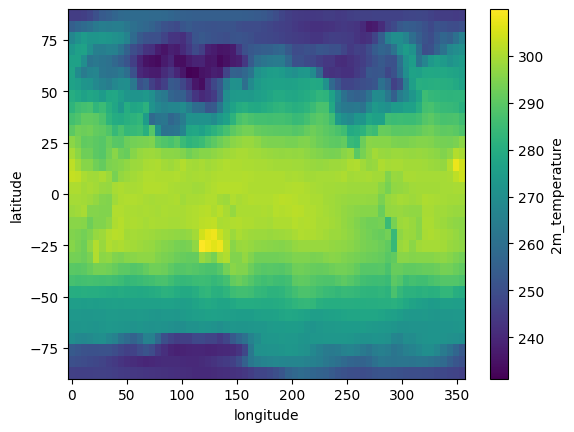

In [11]:
ds_output['2m_temperature'].plot(x='longitude', y='latitude')